# PhysioNet — Holdout Demo Sessions + Evaluation (50 sujeitos)

## Pipeline
1. Divide os segmentos de cada sujeito em **treino (80 %) / holdout (20 %)**, com `random_state` fixo.
2. Treina o classificador em cascata **apenas com os 80 %**.
3. Realiza Cross-Validation do modelo total no usando o treino.
4. Avalia os 3 classificadores individualmente no holdout (GATING, AXIS, DIRECTION).
5. Gera a sessão demo (`eeg_raw.csv`, `markers.csv`, etc.) **exclusivamente com dados raw holdout**.

### Cascata
```
[1] GATING    → REST (0)  vs ACTIVE (1)
                      ↓ se ACTIVE
[2] AXIS      → Mãos (0) vs Pés   (1)
                      ↓ se Mãos
[3] DIRECTION → Esq  (1) vs Dir   (2)
```

In [ ]:
!pip install mne openpyxl --quiet

In [2]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import mne
from mne.datasets import eegbci
from mne.io import read_raw_edf
from mne.decoding import CSP

from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    cohen_kappa_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
)
from sklearn.model_selection import StratifiedKFold

mne.set_log_level("WARNING")
print("\u2713 Imports OK")

✓ Imports OK


## Parâmetros

In [3]:
# ============================================================
# PARÂMETROS
# ============================================================

SUBJECTS     = list(range(1, 51))
HOLDOUT_FRAC = 0.20          # 20 % reservado para avaliação e demo
RANDOM_SEED  = 42

L_FREQ     = 8.0
H_FREQ     = 30.0
EPOCH_TMIN = 1.0
EPOCH_TMAX = 3.5
N_CSP      = 4
N_FOLDS    = 5

CHANNELS_8 = ["FC3", "FC4", "C3", "C4", "CP3", "CP4", "Cz", "FCz"]

RUNS_HANDS = [4, 8, 12]
RUNS_FEET  = [6, 10, 14]
RUNS_REST  = [1, 2]

# --- Proporções da sessão demo ---
N_LEFT  = 8
N_RIGHT = 8
N_FEET  = 6

CUE_DURATION   = 2.0
MI_DURATION    = 4.0
BLOCK_DURATION = CUE_DURATION + MI_DURATION

# Pasta de saída
try:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = "/content/drive/MyDrive/BCI_RoboticArm/HoldoutDemo"
except Exception:
    OUT_DIR = "./holdout_demo_sessions"

os.makedirs(OUT_DIR, exist_ok=True)
print(f"\u2713 Output em: {OUT_DIR}")
print(f"\u2713 Holdout: {int(HOLDOUT_FRAC*100)}%  Treino: {int((1-HOLDOUT_FRAC)*100)}%")

Mounted at /content/drive
✓ Output em: /content/drive/MyDrive/BCI_RoboticArm/HoldoutDemo
✓ Holdout: 20%  Treino: 80%


In [10]:
# ============================================================
# PARÂMETROS
# ============================================================

SUBJECTS     = list(range(1, 51))
DEMO_FRAC    = 0.15          # 15 % reservado exclusivamente para a demo
RANDOM_SEED  = 42

L_FREQ     = 8.0
H_FREQ     = 30.0
EPOCH_TMIN = 1.0
EPOCH_TMAX = 3.5
N_CSP      = 4
N_FOLDS    = 5

CHANNELS_8 = ["FC3", "FC4", "C3", "C4", "CP3", "CP4", "Cz", "FCz"]

RUNS_HANDS = [4, 8, 12]
RUNS_FEET  = [6, 10, 14]
RUNS_REST  = [1, 2]

# --- Proporções da sessão demo ---
N_LEFT  = 8
N_RIGHT = 8
N_FEET  = 6

CUE_DURATION   = 2.0
MI_DURATION    = 4.0
BLOCK_DURATION = CUE_DURATION + MI_DURATION

# Pasta de saída
try:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = "/content/drive/MyDrive/BCI_RoboticArm/HoldoutDemo"
except Exception:
    OUT_DIR = "./holdout_demo_sessions"

os.makedirs(OUT_DIR, exist_ok=True)
print(f"✓ Output em: {OUT_DIR}")
print(f"✓ Demo: {int(DEMO_FRAC*100)}%  CV: {int((1-DEMO_FRAC)*100)}%  ({N_FOLDS}-Fold)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Output em: /content/drive/MyDrive/BCI_RoboticArm/HoldoutDemo
✓ Demo: 15%  CV: 85%  (5-Fold)


## Funções de pré-processamento e extração de épocas

In [4]:
def extract_epochs_by_annotation(raw, ann_label_map, tmin, tmax):
    """
    Extrai épocas filtradas a partir das anotações do raw.
    ann_label_map: e.g. {"T1": 1, "T2": 2}
    """
    events, event_id = mne.events_from_annotations(raw, verbose=False)
    reverse = {v: str(k) for k, v in event_id.items()}

    selected_events, labels = [], []
    for ev in events:
        ann = reverse.get(ev[2], "")
        if ann in ann_label_map:
            selected_events.append(ev)
            labels.append(ann_label_map[ann])

    if not selected_events:
        return np.array([]), np.array([])

    selected_events = np.array(selected_events)
    sfreq   = raw.info["sfreq"]
    data    = raw.get_data()
    t_samps = int((tmax - tmin) * sfreq) + 1

    X_list, y_list = [], []
    for ev, lbl in zip(selected_events, labels):
        start = ev[0] + int(tmin * sfreq)
        end   = start + t_samps
        if end > data.shape[1]:
            continue
        X_list.append(data[:, start:end])
        y_list.append(lbl)

    if not X_list:
        return np.array([]), np.array([])

    return np.stack(X_list), np.array(y_list)


print("\u2713 extract_epochs_by_annotation definida.")

✓ extract_epochs_by_annotation definida.


## Funções de segmentos raw (para a sessão demo)

In [5]:
def extract_mi_segments_raw(raw, min_duration_sec):
    """Extrai segmentos de sinal bruto (sem filtro) para T1 e T2."""
    events, event_id = mne.events_from_annotations(raw, verbose=False)
    sfreq     = raw.info["sfreq"]
    min_samps = int(min_duration_sec * sfreq)
    data      = raw.get_data()
    reverse   = {v: k for k, v in event_id.items()}
    segs      = {}

    for i, ev in enumerate(events):
        label = str(reverse[ev[2]])
        if label not in ("T1", "T2"):
            continue
        start = ev[0]
        trial_end = events[i + 1, 0] if i + 1 < len(events) else min(start + int(6.0 * sfreq), data.shape[1])
        if (trial_end - start) < min_samps:
            continue
        segs.setdefault(label, []).append(data[:, start : start + min_samps])

    return segs


def extract_rest_segments_raw(raw, min_duration_sec):
    """Extrai janelas deslizantes de baseline (sinal bruto)."""
    sfreq     = raw.info["sfreq"]
    min_samps = int(min_duration_sec * sfreq)
    data      = raw.get_data()
    segs      = []
    for start in range(0, data.shape[1] - min_samps, min_samps):
        segs.append(data[:, start : start + min_samps])
    return segs


def pick_segment(seg, n_samps):
    """Devolve exactamente n_samps amostras de seg."""
    if seg.shape[1] >= n_samps:
        offset = random.randint(0, seg.shape[1] - n_samps)
        return seg[:, offset : offset + n_samps]
    else:
        reps = int(np.ceil(n_samps / seg.shape[1]))
        return np.tile(seg, (1, reps))[:, :n_samps]


def split_raw_segs(segs, holdout_frac, seed):
    """Divide lista de segmentos raw em treino e holdout."""
    n   = len(segs)
    idx = np.arange(n)
    rng = np.random.default_rng(seed)
    rng.shuffle(idx)
    n_holdout = max(1, int(np.ceil(n * holdout_frac)))
    return [segs[i] for i in idx[n_holdout:]], [segs[i] for i in idx[:n_holdout]]


print("\u2713 Funções de segmentos raw definidas.")

✓ Funções de segmentos raw definidas.


## Classificador em Cascata

In [6]:
def make_pipeline():
    return Pipeline([
        ("csp",    CSP(n_components=N_CSP, reg="ledoit_wolf", log=True)),
        ("scaler", StandardScaler()),
        ("lda",    LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")),
    ])


def train_cascade(X_hands_train, y_hands_train,
                  X_feet_train,  y_feet_train,
                  X_rest_train):
    """Treina os 3 classificadores binários da cascata."""
    # GATING: REST(0) vs ACTIVE(1)
    X_all_active = np.concatenate([X_hands_train, X_feet_train], axis=0)
    y_gating = np.concatenate([
        np.ones(X_all_active.shape[0], dtype=int),
        np.zeros(X_rest_train.shape[0], dtype=int),
    ])
    X_gating = np.concatenate([X_all_active, X_rest_train], axis=0)
    clf_gating = make_pipeline()
    clf_gating.fit(X_gating, y_gating)

    # AXIS: Mãos(0) vs Pés(1)
    y_axis = np.concatenate([
        np.zeros(X_hands_train.shape[0], dtype=int),
        np.ones(X_feet_train.shape[0],  dtype=int),
    ])
    X_axis = np.concatenate([X_hands_train, X_feet_train], axis=0)
    clf_axis = make_pipeline()
    clf_axis.fit(X_axis, y_axis)

    # DIRECTION: LEFT(1) vs RIGHT(2) — só mãos
    clf_dir = make_pipeline()
    clf_dir.fit(X_hands_train, y_hands_train)

    return clf_gating, clf_axis, clf_dir


def cascade_predict(clf_gating, clf_axis, clf_dir, X):
    """Aplica a cascata de classificadores a um batch de épocas."""
    preds = np.zeros(len(X), dtype=int)

    gate       = clf_gating.predict(X)
    active_idx = np.where(gate == 1)[0]
    if len(active_idx) == 0:
        return preds

    axis      = clf_axis.predict(X[active_idx])
    hands_idx = active_idx[axis == 0]
    feet_idx  = active_idx[axis == 1]
    preds[feet_idx] = 3

    if len(hands_idx) > 0:
        preds[hands_idx] = clf_dir.predict(X[hands_idx])

    return preds


print("\u2713 Classificador em cascata definido.")

✓ Classificador em cascata definido.


## Pipeline principal: Split → Treino → Avaliação → Demo Session

In [20]:
all_results = {}

for subject in SUBJECTS:
    print(f"\n{'='*60}")
    print(f"  SUJEITO {subject}")
    print(f"{'='*60}")

    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

    # ----------------------------------------------------------
    # 1. CARREGAR DADOS
    # ----------------------------------------------------------
    print("  [1/5] A carregar dados do PhysioNet...")

    raw_hands_list, raw_feet_list, raw_rest_list = [], [], []

    for run in RUNS_HANDS:
        p = eegbci.load_data(subject, runs=[run])[0]
        r = read_raw_edf(p, preload=True, verbose=False)
        eegbci.standardize(r)
        raw_hands_list.append(r)

    for run in RUNS_FEET:
        p = eegbci.load_data(subject, runs=[run])[0]
        r = read_raw_edf(p, preload=True, verbose=False)
        eegbci.standardize(r)
        raw_feet_list.append(r)

    for run in RUNS_REST:
        p = eegbci.load_data(subject, runs=[run])[0]
        r = read_raw_edf(p, preload=True, verbose=False)
        eegbci.standardize(r)
        raw_rest_list.append(r)

    # ----------------------------------------------------------
    # 2. EXTRAIR SEGMENTOS RAW (SEM FILTRO) → para demo session
    # ----------------------------------------------------------
    print("  [2/5] A extrair segmentos raw para a demo...")

    left_segs_raw, right_segs_raw, feet_segs_raw, rest_segs_raw = [], [], [], []

    for r in raw_hands_list:
        r_pick = r.copy()
        r_pick.pick_channels(CHANNELS_8)
        segs = extract_mi_segments_raw(r_pick, MI_DURATION)
        left_segs_raw.extend(segs.get("T1", []))
        right_segs_raw.extend(segs.get("T2", []))

    for r in raw_feet_list:
        r_pick = r.copy()
        r_pick.pick_channels(CHANNELS_8)
        segs = extract_mi_segments_raw(r_pick, MI_DURATION)
        feet_segs_raw.extend(segs.get("T2", []))

    for r in raw_rest_list:
        r_pick = r.copy()
        r_pick.pick_channels(CHANNELS_8)
        rest_segs_raw.extend(extract_rest_segments_raw(r_pick, MI_DURATION))

    print(f"    LEFT={len(left_segs_raw)}  RIGHT={len(right_segs_raw)}  "
          f"FEET={len(feet_segs_raw)}  REST={len(rest_segs_raw)}")

    # ----------------------------------------------------------
    # 3. EXTRAIR ÉPOCAS FILTRADAS → para o classificador
    # ----------------------------------------------------------
    print("  [3/5] A filtrar e extrair épocas...")

    def filt_raw(raw_list):
        r = mne.concatenate_raws([x.copy() for x in raw_list])
        r.set_montage(mne.channels.make_standard_montage("standard_1005"),
                      on_missing="ignore", verbose=False)
        r.set_eeg_reference("average", verbose=False)
        r.filter(L_FREQ, H_FREQ, fir_design="firwin", verbose=False)
        r.pick_channels(CHANNELS_8)
        return r

    raw_hands_filt = filt_raw(raw_hands_list)
    raw_feet_filt  = filt_raw(raw_feet_list)
    raw_rest_filt  = filt_raw(raw_rest_list)

    X_hands_all, y_hands_all = extract_epochs_by_annotation(
        raw_hands_filt, {"T1": 1, "T2": 2}, EPOCH_TMIN, EPOCH_TMAX)

    X_feet_all, y_feet_all = extract_epochs_by_annotation(
        raw_feet_filt, {"T2": 3}, EPOCH_TMIN, EPOCH_TMAX)

    sfreq     = raw_rest_filt.info["sfreq"]
    rest_data = raw_rest_filt.get_data()
    n_samps   = int((EPOCH_TMAX - EPOCH_TMIN) * sfreq) + 1
    rest_epochs = [rest_data[:, s:s + n_samps]
                   for s in range(0, rest_data.shape[1] - n_samps, n_samps)]
    X_rest_all = np.stack(rest_epochs)
    y_rest_all = np.zeros(len(X_rest_all), dtype=int)

    print(f"    Mãos={X_hands_all.shape[0]}  Pés={X_feet_all.shape[0]}  REST={X_rest_all.shape[0]}")

    # ----------------------------------------------------------
    # 4a. SEPARAR DEMO (15 %) — nunca mais tocada até ao fim
    # ----------------------------------------------------------
    print(f"  [4/5] A separar demo ({int(DEMO_FRAC*100)}%) e a preparar CV...")

    idx_h = np.arange(len(X_hands_all))
    idx_h_cv, idx_h_demo = train_test_split(
        idx_h, test_size=DEMO_FRAC,
        random_state=RANDOM_SEED, stratify=y_hands_all)

    idx_f = np.arange(len(X_feet_all))
    idx_f_cv, idx_f_demo = train_test_split(
        idx_f, test_size=DEMO_FRAC, random_state=RANDOM_SEED)

    idx_r = np.arange(len(X_rest_all))
    idx_r_cv, idx_r_demo = train_test_split(
        idx_r, test_size=DEMO_FRAC, random_state=RANDOM_SEED)

    # Épocas reservadas para demo/test (cofre)
    X_hands_demo = X_hands_all[idx_h_demo]; y_hands_demo = y_hands_all[idx_h_demo]
    X_feet_demo  = X_feet_all[idx_f_demo]
    X_rest_demo  = X_rest_all[idx_r_demo]

    # Segmentos raw reservados para demo (cofre)
    left_tr_raw,  left_demo_raw  = split_raw_segs(left_segs_raw,  DEMO_FRAC, RANDOM_SEED)
    right_tr_raw, right_demo_raw = split_raw_segs(right_segs_raw, DEMO_FRAC, RANDOM_SEED)
    feet_tr_raw,  feet_demo_raw  = split_raw_segs(feet_segs_raw,  DEMO_FRAC, RANDOM_SEED)
    rest_tr_raw,  rest_demo_raw  = split_raw_segs(rest_segs_raw,  DEMO_FRAC, RANDOM_SEED)

    for name, lst in [("LEFT", left_demo_raw), ("RIGHT", right_demo_raw),
                      ("FEET", feet_demo_raw),  ("REST",  rest_demo_raw)]:
        if not lst:
            raise ValueError(f"Sem segmentos demo para {name} no sujeito {subject}!")

    # ----------------------------------------------------------
    # 4b. STRATIFIED 5-FOLD CV nos restantes 85 % — cascata completa
    # ----------------------------------------------------------
    X_cv_all = np.concatenate([
        X_hands_all[idx_h_cv],
        X_feet_all[idx_f_cv],
        X_rest_all[idx_r_cv],
    ])
    y_cv_all = np.concatenate([
        y_hands_all[idx_h_cv],
        np.full(len(idx_f_cv), 3, dtype=int),
        np.zeros(len(idx_r_cv), dtype=int),
    ])

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    fold_accs, fold_kappas = [], []

    for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(X_cv_all, y_cv_all)):
        X_tr, X_val = X_cv_all[tr_idx], X_cv_all[val_idx]
        y_tr, y_val = y_cv_all[tr_idx], y_cv_all[val_idx]

        mask_hands_tr = np.isin(y_tr, [1, 2])
        mask_feet_tr  = (y_tr == 3)
        mask_rest_tr  = (y_tr == 0)

        clf_g, clf_a, clf_d = train_cascade(
            X_tr[mask_hands_tr], y_tr[mask_hands_tr],
            X_tr[mask_feet_tr],  y_tr[mask_feet_tr],
            X_tr[mask_rest_tr],
        )

        y_pred = cascade_predict(clf_g, clf_a, clf_d, X_val)
        fold_accs.append(np.mean(y_pred == y_val))
        fold_kappas.append(cohen_kappa_score(y_val, y_pred))

        print(f"    Fold {fold_idx+1}/{N_FOLDS} → acc={fold_accs[-1]*100:.1f}%  kappa={fold_kappas[-1]:.3f}")

    cv_acc_mean   = np.mean(fold_accs)
    cv_acc_std    = np.std(fold_accs)
    cv_kappa_mean = np.mean(fold_kappas)
    cv_kappa_std  = np.std(fold_kappas)

    print(f"  CV → acc={cv_acc_mean*100:.1f}% ± {cv_acc_std*100:.1f}%  "
          f"kappa={cv_kappa_mean:.3f} ± {cv_kappa_std:.3f}")

    # ----------------------------------------------------------
    # 5a. MODELO FINAL — treinado em todos os 85 %
    # ----------------------------------------------------------
    print("  [5/5] A treinar modelo final...")

    mask_hands = np.isin(y_cv_all, [1, 2])
    mask_feet  = (y_cv_all == 3)
    mask_rest  = (y_cv_all == 0)

    clf_gating, clf_axis, clf_dir = train_cascade(
        X_cv_all[mask_hands], y_cv_all[mask_hands],
        X_cv_all[mask_feet],  y_cv_all[mask_feet],
        X_cv_all[mask_rest],
    )

    # ----------------------------------------------------------
    # 5b. AVALIAR MODELO FINAL NO DEMO/TEST SET
    #     — cascata completa + cada classificador individualmente
    # ----------------------------------------------------------

    # GATING: REST(0) vs ACTIVE(1)
    X_gate_demo = np.concatenate([X_hands_demo, X_feet_demo, X_rest_demo])
    y_gate_demo = np.concatenate([
        np.ones(len(X_hands_demo) + len(X_feet_demo), dtype=int),
        np.zeros(len(X_rest_demo), dtype=int),
    ])
    y_gate_pred = clf_gating.predict(X_gate_demo)
    acc_gating  = np.mean(y_gate_pred == y_gate_demo)

    # AXIS: Mãos(0) vs Pés(1)
    X_axis_demo = np.concatenate([X_hands_demo, X_feet_demo])
    y_axis_demo = np.concatenate([
        np.zeros(len(X_hands_demo), dtype=int),
        np.ones(len(X_feet_demo),  dtype=int),
    ])
    y_axis_pred = clf_axis.predict(X_axis_demo)
    acc_axis    = np.mean(y_axis_pred == y_axis_demo)

    # DIRECTION: LEFT(1) vs RIGHT(2)
    y_dir_pred = clf_dir.predict(X_hands_demo)
    acc_dir    = np.mean(y_dir_pred == y_hands_demo)

    # CASCATA COMPLETA no demo/test set
    X_eval = np.concatenate([X_hands_demo, X_feet_demo, X_rest_demo])
    y_true = np.concatenate([
        y_hands_demo,
        np.full(len(X_feet_demo), 3, dtype=int),
        np.zeros(len(X_rest_demo), dtype=int),
    ])
    y_pred      = cascade_predict(clf_gating, clf_axis, clf_dir, X_eval)
    acc_test    = np.mean(y_pred == y_true)
    kappa_test  = cohen_kappa_score(y_true, y_pred)
    bal_test    = balanced_accuracy_score(y_true, y_pred)
    f1_test     = f1_score(y_true, y_pred, average="macro", zero_division=0)

    print(f"  Test → acc={acc_test*100:.1f}%  kappa={kappa_test:.3f}  "
          f"Gating={acc_gating*100:.1f}%  Axis={acc_axis*100:.1f}%  Dir={acc_dir*100:.1f}%")

    all_results[subject] = {
        # CV (cascata)
        "cv_acc_mean":   cv_acc_mean,   "cv_acc_std":   cv_acc_std,
        "cv_kappa_mean": cv_kappa_mean, "cv_kappa_std": cv_kappa_std,
        # Test set (demo) — cascata
        "acc_test":  acc_test,  "kappa_test": kappa_test,
        "bal_test":  bal_test,  "f1_test":    f1_test,
        # Test set (demo) — classificadores individuais
        "acc_gating": acc_gating,
        "acc_axis":   acc_axis,
        "acc_dir":    acc_dir,
    }

    # ----------------------------------------------------------
    # 5c. GERAR SESSÃO DEMO COM DADOS DEMO RAW (cofre)
    # ----------------------------------------------------------
    sfreq_demo  = raw_hands_list[0].info["sfreq"]
    n_mi_samps  = int(MI_DURATION    * sfreq_demo)
    n_blk_samps = int(BLOCK_DURATION * sfreq_demo)

    active = ([1] * N_LEFT) + ([2] * N_RIGHT) + ([3] * N_FEET)
    random.shuffle(active)
    sequence = []
    for cls in active:
        sequence.append(0)
        sequence.append(cls)

    demo_pool = {0: rest_demo_raw, 1: left_demo_raw, 2: right_demo_raw, 3: feet_demo_raw}

    eeg_blocks, markers, t = [], [], 0.0
    for label in sequence:
        pool    = demo_pool[label]
        mi_seg  = pick_segment(random.choice(pool), n_mi_samps)
        cue_seg = pick_segment(random.choice(rest_demo_raw), n_blk_samps - n_mi_samps)
        block   = np.concatenate([cue_seg, mi_seg], axis=1)
        assert block.shape[1] == n_blk_samps
        markers.append([t,                  "cue_on",   label])
        markers.append([t + CUE_DURATION,   "mi_start", label])
        markers.append([t + BLOCK_DURATION, "mi_end",   label])
        eeg_blocks.append(block)
        t += BLOCK_DURATION

    eeg       = np.concatenate(eeg_blocks, axis=1)
    n_samples = eeg.shape[1]
    times     = np.arange(n_samples) / sfreq_demo

    demo_dir = os.path.join(OUT_DIR, f"S{subject:03d}_demo")
    os.makedirs(demo_dir, exist_ok=True)

    eeg_df = pd.DataFrame(eeg.T, columns=[f"ch_{i}" for i in range(8)])
    eeg_df["timestamp"] = times
    eeg_df.to_csv(os.path.join(demo_dir, "eeg_raw.csv"), index=False)

    pd.DataFrame(markers, columns=["timestamp", "event", "label"]).to_csv(
        os.path.join(demo_dir, "markers.csv"), index=False)

    metadata = {
        "sampling_rate": float(sfreq_demo), "eeg_channels": list(range(8)),
        "classes": {
            "REST":  {"label": 0, "symbol": "+"},
            "LEFT":  {"label": 1, "symbol": "←"},
            "RIGHT": {"label": 2, "symbol": "→"},
            "FEET":  {"label": 3, "symbol": "↓"},
        },
        "fixation_time": 2.0, "cue_time": 2.0,
        "imagery_time": float(MI_DURATION), "rest_time": 2.0,
        "baseline_open": 0, "baseline_closed": 0,
        "demo_fraction": DEMO_FRAC,
        "cv_folds": N_FOLDS,
        "note": "Sessão gerada EXCLUSIVAMENTE com dados demo (não vistos pelo modelo)."
    }
    with open(os.path.join(demo_dir, "metadata.json"), "w") as fj:
        json.dump(metadata, fj, indent=4)
    with open(os.path.join(demo_dir, "sfreq.txt"), "w") as fs:
        fs.write(str(sfreq_demo))

    joblib.dump(clf_gating, os.path.join(demo_dir, "clf_gating.pkl"))
    joblib.dump(clf_axis,   os.path.join(demo_dir, "clf_axis.pkl"))
    joblib.dump(clf_dir,    os.path.join(demo_dir, "clf_dir.pkl"))

    print(f"  → {demo_dir}/ (demo guardada)")

print("\n\n✓ DONE — sessions geradas em:", OUT_DIR)


  SUJEITO 1
  [1/5] A carregar dados do PhysioNet...
  [2/5] A extrair segmentos raw para a demo...
    LEFT=23  RIGHT=22  FEET=24  REST=30
  [3/5] A filtrar e extrair épocas...
    Mãos=45  Pés=24  REST=48
  [4/5] A separar demo (15%) e a preparar CV...
    Fold 1/5 → acc=60.0%  kappa=0.481
    Fold 2/5 → acc=55.0%  kappa=0.392
    Fold 3/5 → acc=60.0%  kappa=0.452
    Fold 4/5 → acc=52.6%  kappa=0.350
    Fold 5/5 → acc=57.9%  kappa=0.374
  CV → acc=57.1% ± 2.9%  kappa=0.410 ± 0.049
  [5/5] A treinar modelo final...
  Test → acc=52.6%  kappa=0.362  Gating=63.2%  Axis=100.0%  Dir=71.4%
  → /content/drive/MyDrive/BCI_RoboticArm/HoldoutDemo/S001_demo/ (demo guardada)

  SUJEITO 2
  [1/5] A carregar dados do PhysioNet...
  [2/5] A extrair segmentos raw para a demo...
    LEFT=23  RIGHT=22  FEET=21  REST=30
  [3/5] A filtrar e extrair épocas...
    Mãos=45  Pés=21  REST=48
  [4/5] A separar demo (15%) e a preparar CV...
    Fold 1/5 → acc=52.6%  kappa=0.364
    Fold 2/5 → acc=47.4%  kapp

## Tabela de Resultados

In [22]:
df_res = pd.DataFrame([
    {
        "Sujeito":           f"S{s}",
        # Cascata — Cross-Validation
        "CV Acc (%)":        f"{v['cv_acc_mean']*100:.1f}",
        "CV Acc Std (%)":    f"{v['cv_acc_std']*100:.1f}",
        "CV Kappa":          f"{v['cv_kappa_mean']:.3f}",
        "CV Kappa Std":      f"{v['cv_kappa_std']:.3f}",
        # Cascata — Test set (demo)
        "Test Acc (%)":      f"{v['acc_test']*100:.1f}",
        "Test Kappa":        f"{v['kappa_test']:.3f}",
        "Test Bal. Acc (%)": f"{v['bal_test']*100:.1f}",
        "Test F1 (macro)":   f"{v['f1_test']:.3f}",
        # Classificadores individuais — Test set (demo)
        "Gating Acc (%)":    f"{v['acc_gating']*100:.1f}",
        "Axis Acc (%)":      f"{v['acc_axis']*100:.1f}",
        "Dir Acc (%)":       f"{v['acc_dir']*100:.1f}",
    }
    for s, v in all_results.items()
])

print(f"\n=== Resultados — {N_FOLDS}-Fold CV + Test Set (demo {int(DEMO_FRAC*100)}%) ===")
print(df_res.to_string(index=False))

res_path = os.path.join(OUT_DIR, "cv_results.csv")
df_res.to_csv(res_path, index=False)
print(f"\n✓ Resultados guardados em: {res_path}")


=== Resultados — 5-Fold CV + Test Set (demo 15%) ===
Sujeito CV Acc (%) CV Acc Std (%) CV Kappa CV Kappa Std Test Acc (%) Test Kappa Test Bal. Acc (%) Test F1 (macro) Gating Acc (%) Axis Acc (%) Dir Acc (%)
     S1       57.1            2.9    0.410        0.049         52.6      0.362              55.2           0.508           63.2        100.0        71.4
     S2       56.8            6.1    0.413        0.072         63.2      0.506              60.4           0.593           89.5         72.7        71.4
     S3       74.5           11.8    0.643        0.167         84.2      0.777              79.2           0.792          100.0         81.8        85.7
     S4       76.3            6.7    0.669        0.092         84.2      0.778              84.4           0.835           89.5         90.9       100.0
     S5       46.9            6.7    0.243        0.102         47.4      0.224              36.5           0.327           73.7         54.5        57.1
     S6       53.6    

## Barplot — Accuracy por sujeito (igual ao PoC original)

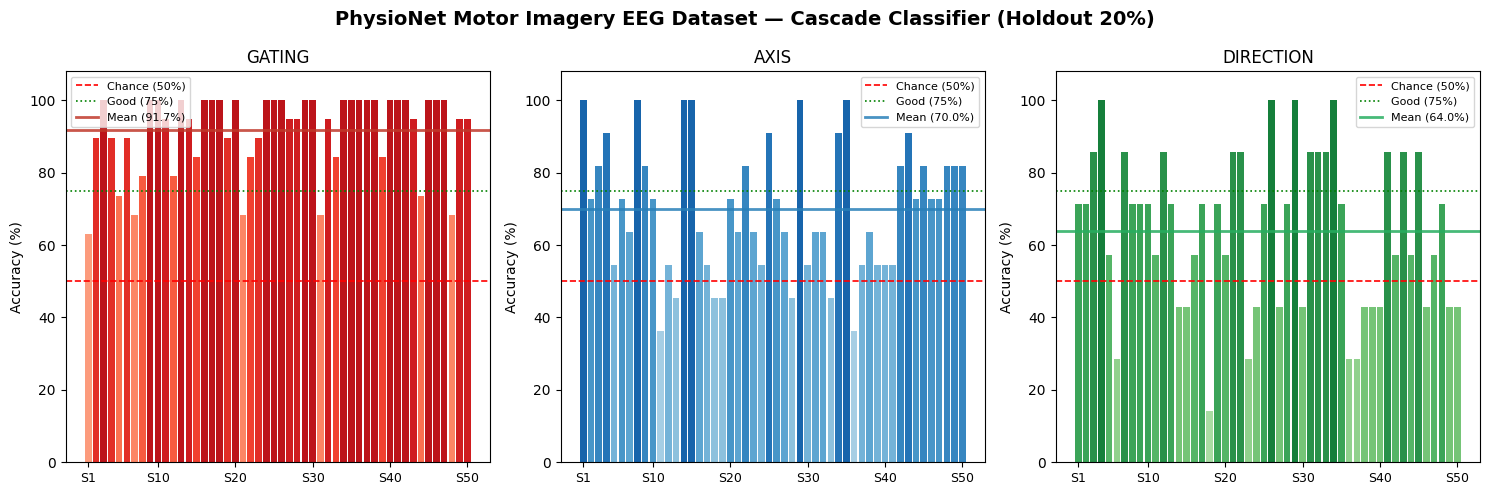

✓ Barplot guardado: /content/drive/MyDrive/BCI_RoboticArm/HoldoutDemo/cascade_poc_barplot.png


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("PhysioNet Motor Imagery EEG Dataset — Cascade Classifier (Holdout 20%)",
             fontsize=14, fontweight="bold")

classifiers = [
    ("GATING",    "acc_gating", "Reds",   "#c0392b"),
    ("AXIS",      "acc_axis",   "Blues",  "#2980b9"),
    ("DIRECTION", "acc_dir",    "Greens", "#27ae60"),
]

subjects = list(all_results.keys())
x_pos    = np.arange(len(subjects))

for ax, (name, acc_key, cmap_name, line_color) in zip(axes, classifiers):
    accs = np.array([all_results[s][acc_key] * 100 for s in subjects])

    cmap   = plt.get_cmap(cmap_name)
    colors = [cmap(0.35 + 0.45 * (a - accs.min()) / (accs.max() - accs.min() + 1e-9))
              for a in accs]

    ax.bar(x_pos, accs, color=colors, edgecolor="none", width=0.85)

    ax.axhline(50, color="red",   linestyle="--", linewidth=1.2, label="Chance (50%)")
    ax.axhline(75, color="green", linestyle=":",  linewidth=1.2, label="Good (75%)")
    ax.axhline(accs.mean(), color=line_color, linestyle="-",
               linewidth=2.0, alpha=0.85, label=f"Mean ({accs.mean():.1f}%)")

    ax.set_ylim(0, 108)
    ax.set_ylabel("Accuracy (%)")
    ax.set_title(name)

    tick_positions = np.linspace(0, len(subjects) - 1, 6, dtype=int)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([f"S{subjects[i]}" for i in tick_positions], fontsize=9)
    ax.legend(fontsize=8)

plt.tight_layout()

barplot_path = os.path.join(OUT_DIR, "cascade_poc_barplot.png")
plt.savefig(barplot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\u2713 Barplot guardado: {barplot_path}")

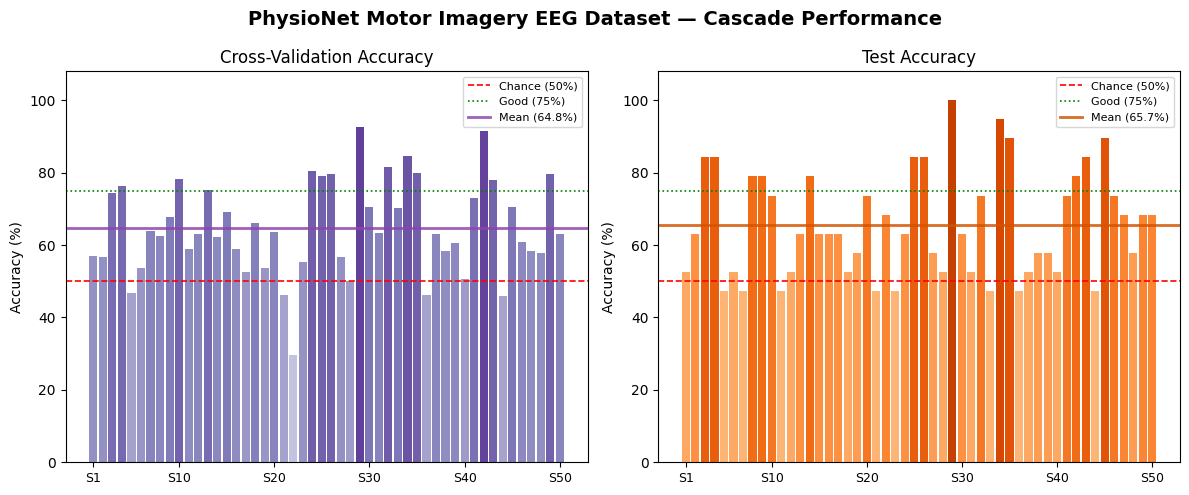

✓ Gráfico guardado: /content/drive/MyDrive/BCI_RoboticArm/HoldoutDemo/cv_vs_test_accuracy.png


In [24]:
# ============================================================
# CV Accuracy vs Test Accuracy
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fig.suptitle(
    "PhysioNet Motor Imagery EEG Dataset — Cascade Performance",
    fontsize=14,
    fontweight="bold"
)

metrics = [
    ("Cross-Validation Accuracy", "cv_acc_mean", "Purples", "#8e44ad"),
    ("Test Accuracy",             "acc_test",    "Oranges", "#d35400"),
]

subjects = list(all_results.keys())
x_pos = np.arange(len(subjects))

for ax, (title, key, cmap_name, line_color) in zip(axes, metrics):

    values = np.array([
        all_results[s][key] * 100
        for s in subjects
    ])

    cmap = plt.get_cmap(cmap_name)

    colors = [
        cmap(
            0.35 + 0.45 *
            (v - values.min()) /
            (values.max() - values.min() + 1e-9)
        )
        for v in values
    ]

    ax.bar(
        x_pos,
        values,
        color=colors,
        edgecolor="none",
        width=0.85
    )

    ax.axhline(
        50,
        color="red",
        linestyle="--",
        linewidth=1.2,
        label="Chance (50%)"
    )

    ax.axhline(
        75,
        color="green",
        linestyle=":",
        linewidth=1.2,
        label="Good (75%)"
    )

    ax.axhline(
        values.mean(),
        color=line_color,
        linestyle="-",
        linewidth=2,
        alpha=0.85,
        label=f"Mean ({values.mean():.1f}%)"
    )

    ax.set_ylim(0, 108)
    ax.set_ylabel("Accuracy (%)")
    ax.set_title(title)

    tick_positions = np.linspace(
        0,
        len(subjects) - 1,
        min(6, len(subjects)),
        dtype=int
    )

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(
        [f"S{subjects[i]}" for i in tick_positions],
        fontsize=9
    )

    ax.legend(fontsize=8)

plt.tight_layout()

cv_test_plot_path = os.path.join(
    OUT_DIR,
    "cv_vs_test_accuracy.png"
)

plt.savefig(
    cv_test_plot_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(f"✓ Gráfico guardado: {cv_test_plot_path}")